# Branched Signature Kernel Model for single trajectory rough linear ODEs

## Problem Introduction

The Problem is:

$$
\begin{align*}
&a(x) u''(x)+b(x) u'(x)+c(x) u(x)=f(x)\\
&u(0)=a\\
&u'(0)=b
\end{align*}
$$
with constants $a,b$ and functions of x as coefficients $a,b,c$.


## Imports

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 5.3 MB/s eta 0:00:00
Using device: cuda torch 2.10.0+cu128


In [ ]:
# Cell 1 - installs + clone
!pip install --quiet torch torchvision jax jaxlib keras_sig numpy matplotlib scipy fbm pytorch-minimize
!git clone https://github.com/CharliePyle4/BSK_ODE.git /content/BSK_ODE 2>/dev/null || git -C /content/BSK_ODE pull

# Cell 2 - import
import sys
sys.path.insert(0, '/content/BSK_ODE')
from bsk_ode import *
print("Using device:", device, "torch", torch.__version__)


## FBM Generator Function

In [ ]:
def f_forcing_fbm(x: torch.Tensor, hurst: float = 0.2) -> torch.Tensor:
    """Fractional Brownian motion on [a,b] using fbm (Davies–Harte)."""
    N = x.numel()
    a_ = float(x[0])
    b_ = float(x[-1])
    length = b_ - a_

    f = FBM(n=N-1, hurst=hurst, length=length, method='daviesharte')
    fbm_sample = f.fbm()
    return torch.tensor(fbm_sample, dtype=x.dtype, device=x.device)

## Reference Solution Function using Scipy Solver

In [ ]:
def solve_linear_ivp(x_grid: torch.Tensor,
                    forcing_torch: torch.Tensor,
                    a: float, b: float,
                    ya: float, ypa: float,
                    a_fun, b_fun, c_fun):
    """
    Solve a(x) u'' + b(x) u' + c(x) u = f(x)
    rewritten as u'' = (f - b(x) u' - c(x) u) / a(x)
    """
    # Work with numpy time grid
    t_eval = x_grid.cpu().numpy()
    f_np = forcing_torch.cpu().numpy()
    dx = t_eval[1] - t_eval[0]

    # Precompute coefficient values on the grid using the torch functions
    # a_fun, b_fun, c_fun are assumed to accept a torch tensor and return a tensor
    a_vec = a_fun(x_grid).cpu().numpy()
    b_vec = b_fun(x_grid).cpu().numpy()
    c_vec = c_fun(x_grid).cpu().numpy()

    def interp(arr, t):
        # nearest‑neighbor lookup on the grid
        idx = int(round((t - t_eval[0]) / dx))
        idx = max(0, min(len(arr) - 1, idx))
        return arr[idx]

    def forcing(t):
        return interp(f_np, t)

    def a_val(t):
        return interp(a_vec, t)

    def b_val(t):
        return interp(b_vec, t)

    def c_val(t):
        return interp(c_vec, t)

    def fun(t, y):
        u, up = y
        f_v = forcing(t)
        av = a_val(t)
        bv = b_val(t)
        cv = c_val(t)
        du_dt = up
        dup_dt = (f_v - bv * up - cv * u) / av
        return [du_dt, dup_dt]

    y0 = [ya, ypa]
    sol = solve_ivp(fun, (a, b), y0, t_eval=t_eval,
                    method="BDF", rtol=1e-10, atol=1e-15, max_step=0.05)
    u_ivp = sol.y[0]
    return (torch.tensor(t_eval, dtype=torch.float64),
            torch.tensor(u_ivp, dtype=torch.float64))

## Signature Kernel Solver Helper Functions

In [ ]:
# === Integration and kernel helpers ===
#integrate kernel matrix
def cumtrapz_torch(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    dx   = x[1:] - x[:-1]
    area = 0.5 * (y[1:] + y[:-1]) * dx
    out  = torch.zeros_like(y)
    out[1:] = torch.cumsum(area, dim=0)
    return out

def double_integrate(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return cumtrapz_torch(cumtrapz_torch(y, x), x)


def forcing_loss(true_forcing, approximated_forcing):
    residual = true_forcing - approximated_forcing
    loss = torch.mean(residual**2)
    return loss

def l2_err(y: torch.Tensor, yref: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return torch.sqrt(torch.trapz((y - yref)**2, x))


def compute_signatures(path: torch.Tensor,
                       depth: int) -> torch.Tensor:
    """
    path: (T, d) or (1, T, d) torch tensor.
    Returns: (T, D) prefix-signature features as torch.Tensor.
    """
    if path.dim() == 2:
        path = path.unsqueeze(0)          # (1, T, d)

    # Prepend basepoint, emulating Signatory's basepoint behaviour
    basepoint = path[:, 0:1, :]           # (1, 1, d)
    path_bp = torch.cat([basepoint, path], dim=1)  # (1, T+1, d)

    # Streaming signatures on the basepoint-augmented path:
    # for length = T+1, stream=True → output length-1 = T
    sigs = keras_sig.signature(
        path_bp,
        depth=depth,
        stream=True,
        gpu_optimized=True
    )                                      # (1, T, D)

    return sigs.squeeze(0)                # (T, D)


def build_kernel_from_signatures(sigs_flat: torch.Tensor,
                                 sigma: float = 1.0,
                                 kernel_type: str = "rbf") -> torch.Tensor:
    """
    Build a kernel matrix from signature features.
    sigs_flat: (T,D)
    """
    if kernel_type == "linear":
        Ker = sigs_flat @ sigs_flat.T
    elif kernel_type == "rbf":
        norms = (sigs_flat ** 2).sum(dim=1, keepdim=True)
        d2 = norms + norms.T - 2 * (sigs_flat @ sigs_flat.T)
        Ker = torch.exp(-d2 / (2 * sigma**2))
    else:
        raise ValueError(f"Unknown kernel_type {kernel_type}")

    return Ker


## Signature Normalization functions

with help from the paper deep signature transforms and their github code

note we need to investigate the scalarterm parameter in signatory and whether to use. for now we will use it

In [ ]:
# --- Normalisation functions on signatures ---
def normalize_none(sigs_flat: torch.Tensor,
                   depth: int,
                   dim: int,
                   **kwargs) -> torch.Tensor:
    """No normalization."""
    return sigs_flat


def normalize_rowwise_unit_norm(Z: torch.Tensor,
                                depth: int,
                                dim: int,
                                eps: float = 1e-8,
                                **kwargs) -> torch.Tensor:
    """
    Row-wise unit-norm scaling.
    For each time t, divide by the row's Euclidean norm:
      Z[t, :] -> Z[t, :] / ||Z[t, :]||_2
    """
    norms = Z.norm(dim=1, keepdim=True)   # (T,1)
    return Z / (norms + eps)


def normalize_colwise_unit_norm(Z: torch.Tensor,
                                depth: int,
                                dim: int,
                                eps: float = 1e-8,
                                **kwargs) -> torch.Tensor:
    """
    Column-wise unit-norm scaling.
    For each feature j, divide by the column's Euclidean norm:
      Z[:, j] -> Z[:, j] / ||Z[:, j]||_2
    """
    norms = Z.norm(dim=0, keepdim=True)   # (1,D)
    return Z / (norms + eps)


def normalize_rowwise_zscore(Z: torch.Tensor,
                             depth: int,
                             dim: int,
                             eps: float = 1e-8,
                             **kwargs) -> torch.Tensor:
    """
    Row-wise z-score normalization.
    For each time t, subtract row mean and divide by row std:
      Z[t, :] -> (Z[t, :] - mean_t) / std_t
    """
    mean = Z.mean(dim=1, keepdim=True)              # (T,1)
    std  = Z.std(dim=1, unbiased=False, keepdim=True)
    return (Z - mean) / (std + eps)


def normalize_colwise_zscore(Z: torch.Tensor,
                             depth: int,
                             dim: int,
                             eps: float = 1e-8,
                             **kwargs) -> torch.Tensor:
    """
    Column-wise z-score normalization.
    For each feature j, subtract feature mean and divide by feature std:
      Z[:, j] -> (Z[:, j] - mu_j) / sigma_j
    """
    mean = Z.mean(dim=0, keepdim=True)              # (1,D)
    std  = Z.std(dim=0, unbiased=False, keepdim=True)
    return (Z - mean) / (std + eps)


def normalize_rowwise_robust(Z: torch.Tensor,
                             depth: int,
                             dim: int,
                             eps: float = 1e-8,
                             **kwargs) -> torch.Tensor:
    """
    Row-wise robust normalization using median and IQR.
    For each time t:
      med_t = median_j Z[t,j]
      q25_t, q75_t = 25th, 75th percentiles over features
      iqr_t = q75_t - q25_t
      Z[t,:] -> (Z[t,:] - med_t) / (iqr_t + eps)
    """
    med = Z.median(dim=1, keepdim=True).values      # (T,1)
    q25 = Z.quantile(0.25, dim=1, keepdim=True)
    q75 = Z.quantile(0.75, dim=1, keepdim=True)
    iqr = q75 - q25
    return (Z - med) / (iqr + eps)


def normalize_colwise_robust(Z: torch.Tensor,
                             depth: int,
                             dim: int,
                             eps: float = 1e-8,
                             **kwargs) -> torch.Tensor:
    """
    Column-wise robust normalization using median and IQR.
    For each feature j:
      med_j = median_t Z[t,j]
      q25_j, q75_j = 25th, 75th percentiles over time
      iqr_j = q75_j - q25_j
      Z[:,j] -> (Z[:,j] - med_j) / (iqr_j + eps)
    """
    med = Z.median(dim=0, keepdim=True).values      # (1,D)
    q25 = Z.quantile(0.25, dim=0, keepdim=True)
    q75 = Z.quantile(0.75, dim=0, keepdim=True)
    iqr = q75 - q25
    return (Z - med) / (iqr + eps)


# Dispatcher
def apply_signature_normalization(sigs_flat: torch.Tensor,
                                  depth: int,
                                  dim: int,
                                  scheme: str,
                                  **kwargs) -> torch.Tensor:
    """
    scheme:
      'none'
      'row_unit'     : row-wise unit-norm
      'col_unit'     : column-wise unit-norm
      'row_zscore'   : row-wise mean/std
      'col_zscore'   : column-wise mean/std
      'row_robust'   : row-wise median/IQR
      'col_robust'   : column-wise median/IQR
    """
    if scheme == "none":
        return normalize_none(sigs_flat, depth, dim, **kwargs)
    elif scheme == "row_unit":
        return normalize_rowwise_unit_norm(sigs_flat, depth, dim, **kwargs)
    elif scheme == "col_unit":
        return normalize_colwise_unit_norm(sigs_flat, depth, dim, **kwargs)
    elif scheme == "row_zscore":
        return normalize_rowwise_zscore(sigs_flat, depth, dim, **kwargs)
    elif scheme == "col_zscore":
        return normalize_colwise_zscore(sigs_flat, depth, dim, **kwargs)
    elif scheme == "row_robust":
        return normalize_rowwise_robust(sigs_flat, depth, dim, **kwargs)
    elif scheme == "col_robust":
        return normalize_colwise_robust(sigs_flat, depth, dim, **kwargs)
    else:
        raise ValueError(f"Unknown normalization scheme '{scheme}'")


## Beta coefficient Calculation Functions

In [ ]:
def build_kernel_operators(Ksig: torch.Tensor,
                           x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Vectorized construction of Ku2, Kup, Ku from Ksig.
    """
    # Ksig: (N, N), integrate along rows (dim=0) w.r.t. x (N,)
    Ku2 = Ksig.clone()  # u''

    # first integral: shape (N-1, N), then pad a leading zero row
    I1 = cumulative_trapezoid(Ku2, x, dim=0)          # (N-1, N)
    I1 = torch.vstack([torch.zeros_like(I1[0:1, :]), I1])  # (N, N)
    Kup = I1

    # second integral: integrate I1 again along x
    I2 = cumulative_trapezoid(I1, x, dim=0)           # (N-1, N)
    I2 = torch.vstack([torch.zeros_like(I2[0:1, :]), I2])  # (N, N)
    Ku = I2

    return Ku2, Kup, Ku


def solve_betas(Ksig: torch.Tensor,
                f: torch.Tensor,
                x: torch.Tensor,
                ua: float,
                upa: float,
                a_fun,
                b_fun,
                c_fun,
                reg: float = 1e-20,    #dummy parameter, not used anymore but kept for compatability
                **kwargs):
    """
    For a(x) u'' + b(x) u' + c(x) u = f(x), solve beta by linear regression.

    Model:
      u'' = Ku2 @ beta
      u'  = upa + Kup @ beta
      u   = ua + upa*(x - x0) + Ku @ beta
    """

    Ku2, Kup, Ku = build_kernel_operators(Ksig, x)
    N  = Ksig.shape[0]
    x0 = x[0]

    # coefficient vectors on grid
    a_vec = a_fun(x)      # shape (N,)
    b_vec = b_fun(x)
    c_vec = c_fun(x)

    # A[i,:] = a(x_i)*Ku2[i,:] + b(x_i)*Kup[i,:] + c(x_i)*Ku[i,:]
    A = a_vec[:, None] * Ku2 + b_vec[:, None] * Kup + c_vec[:, None] * Ku

    # rhs = f - b(x)*upa - c(x)*(ua + upa*(x - x0))
    rhs = f - b_vec * upa - c_vec * (ua + upa * (x - x0))

    ATrhs = A.T @ rhs
    #beta  = torch.linalg.solve(ATA, ATrhs)
    #ATA   = A.T @ A + reg * torch.eye(N, dtype=A.dtype, device=A.device)

    beta = torch.linalg.solve(A.T @ A, A.T @ rhs)

    # reconstruct u, u', u''
    u_dd = Ku2 @ beta
    u_p  = upa + Kup @ beta
    u    = ua + upa * (x - x0) + Ku @ beta

    # predicted forcing
    f_pred = a_vec * u_dd + b_vec * u_p + c_vec * u

    return beta, u, f_pred




# No Signature Mode

In [ ]:
def solve_rbf_kernel_plain(
    x: torch.Tensor,        # (N,)
    f: torch.Tensor,        # (N,)
    a_fun,                  # a_fun(t)
    b_fun,                  # b_fun(t)
    c_fun,                  # c_fun(t)
    ua: float,              # u(a)
    upa: float,             # u'(a)
    rbfsigma: float,        # RBF length-scale σ
):
    """
    Baseline solver using a plain pointwise RBF kernel on the time grid.

    K(t_i, t_j) = exp(-|t_i - t_j|^2 / (2 * σ^2))

    No signatures, no path extensions.
    """
    with torch.no_grad():
        t0 = time.time()

        x64 = x.to(torch.float64)
        f64 = f.to(torch.float64)

        # Plain RBF kernel on time
        diff = x64.unsqueeze(0) - x64.unsqueeze(1)   # (N, N)
        d2   = diff ** 2
        Ksig = torch.exp(-d2 / (2.0 * rbfsigma ** 2))  # (N, N)

        print("finding betas (plain RBF kernel)...")
        t1 = time.time()
        beta, u, fpred = solve_betas(
            Ksig=Ksig,
            f=f64,
            x=x64,
            ua=ua,
            upa=upa,
            a_fun=a_fun,
            b_fun=b_fun,
            c_fun=c_fun,
        )
        t2 = time.time()
        print(f"time solve betas (RBF): {t2 - t1:.3f} s")

        final_loss = forcing_loss(f64, fpred)
        print(f"plain RBF model forcing match loss: {final_loss.item():.3e}")
        print(f"total time RBF-only: {t2 - t0:.3f} s")

    return u, fpred

# Non Branched Signature Kernel Model

In [ ]:
# === Non‑branched (no extension) signature‑kernel solver ===
def solve_signature_kernel_non_branched(x, f,
                                        a_fun, b_fun, c_fun,
                                        ua, upa,
                                        depth, rbf_sigma,
                                        kernel_type: str = "rbf",
                                        norm_scheme: str = "none",
                                        norm_kwargs: dict | None = None):

    if norm_kwargs is None:
        norm_kwargs = {}

    with torch.no_grad():

        t0 = time.time()
        print("building Path")
        X = torch.stack([x, f], dim=1)           # (T,2)
        t1 = time.time()
        print(f"  time (build path): {t1 - t0:.3f} s")

        print("Computing Signatures")
        t2 = time.time()
        X_sig = compute_signatures(X, depth)     # (T,D)
        t3 = time.time()
        print(f"  time (compute signatures): {t3 - t2:.3f} s")

        print("maybe normalizing")
        t4 = time.time()
        X_sig_norm = apply_signature_normalization(
            X_sig, depth=depth, dim=2, scheme=norm_scheme, **norm_kwargs
        )
        t5 = time.time()
        print(f"  time (normalization): {t5 - t4:.3f} s")

        print("building kernel from sigs")
        t6 = time.time()
        Ksig = build_kernel_from_signatures(
            X_sig_norm, sigma=rbf_sigma, kernel_type=kernel_type
        )
        t7 = time.time()
        print(f"  time (build kernel): {t7 - t6:.3f} s")


        Ksig = Ksig.to(torch.float64)
        x    = x.to(torch.float64)
        f    = f.to(torch.float64)

        print("finding betas, evaluating")
        t8 = time.time()
        beta_w, u, f_pred_final = solve_betas(
          Ksig=Ksig,
          f=f,
          x=x,
          ua=ua,
          upa=upa,
          a_fun=a_fun,
          b_fun=b_fun,
          c_fun=c_fun,
        )
        t9 = time.time()
        print(f"  time (solve betas): {t9 - t8:.3f} s")

        print("betas converged, evaluating forcing loss")
        t10 = time.time()
        final_loss = forcing_loss(f, f_pred_final)
        t11 = time.time()
        print(f"  time (forcing loss): {t11 - t10:.3f} s")

        print(f"non-branched model forcing match loss: {final_loss.item():.3e}")
        print(f"total time (non-branched): {t11 - t0:.3f} s")

    return u, f_pred_final


# Branched Signature Kernel model (Neural Network Path Extension)

In [ ]:
class PathExtension(nn.Module):
    def __init__(self,
                 input_dim: int,
                 output_dim: int,
                 hidden_dims=(512, 256, 128, 64, 32, 16),
                 activation_cls=nn.Tanh):
        super().__init__()

        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(activation_cls())
            in_dim = h
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def shuffle_loss_function(X_bar: torch.Tensor) -> torch.Tensor:
    dX = X_bar[1:, :] - X_bar[:-1, :]
    X_left = X_bar[:-1, :]
    I = torch.einsum('ka,kb->ab', X_left, dX)
    deltas = X_bar[-1, :] - X_bar[0, :]
    R = deltas[:, None] * deltas[None, :] - (I + I.T)
    return torch.triu(R.pow(2), diagonal=0).sum()

def shuffle_loss_residual(X_bar: torch.Tensor) -> torch.Tensor:
    """
    Return the full shuffle residual matrix R for the extended path X_bar (T,E):
    """
    dX = X_bar[1:, :] - X_bar[:-1, :]    # (T-1, E)
    X_left = X_bar[:-1, :]               # (T-1, E)
    I = torch.einsum('ka,kb->ab', X_left, dX)  # ∑ X^i ΔX^j over k
    deltas = X_bar[-1, :] - X_bar[0, :]        # (E,)
    R = deltas[:, None] * deltas[None, :] - (I + I.T)
    return R


# === Branched (extended‑path) signature‑kernel solver ===
def solve_signature_kernel_branched(x, f,
                                    a_fun, b_fun, c_fun,
                                    ua, upa,
                                    adam_iters, adam_lr,
                                    ADAM_lambda_model, ADAM_lambda_shuffle,
                                    snapshot_count, hidden_dims,
                                    activation_cls, extensions,
                                    adam_use_scheduler, adam_sched_factor,
                                    adam_sched_patience,
                                    depth, rbf_sigma,
                                    kernel_type: str = "rbf",
                                    norm_scheme: str = "none",
                                    norm_kwargs: dict | None = None):

    if norm_kwargs is None:
        norm_kwargs = {}

    #Build extension network
    path_ext = PathExtension(
        input_dim=2,
        output_dim=extensions,
        hidden_dims=hidden_dims,
        activation_cls=activation_cls
    ).to(device)


    # Optimizer (Adam) over both extension net and beta_w
    snapshots = []
    opt = torch.optim.Adam(
        list(path_ext.parameters()),
        lr=adam_lr
    )

    # Optional LR scheduler
    scheduler = None
    if adam_use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt,
            mode="min",
            factor=adam_sched_factor,
            patience=adam_sched_patience,
        )

    # Build the base path
    X = torch.stack([x, f], dim=1)

    # Snapshot schedule for Adam phase
    num_snaps_adam = snapshot_count
    adam_snapshot_epochs = sorted(set(
        int(i) for i in torch.linspace(1, adam_iters, num_snaps_adam)
    ))
    if 1 in adam_snapshot_epochs:
        adam_snapshot_epochs.remove(1)


    # ---------- Adam phase (jointly train extension + beta_w) ----------
    for it in range(1, adam_iters + 1):
        opt.zero_grad()

        # Compute extensions and shuffle loss
        out_ext = path_ext(X)
        shuffle_loss = shuffle_loss_function(out_ext)

        # Build extended path
        stack = torch.cat([X.unsqueeze(0), out_ext.unsqueeze(0)], dim=2)
        X_ext = stack.squeeze(0)

        # signatures of extended path
        X_ext_sig = compute_signatures(X_ext, depth)

        # normalization on signatures of extended path (if any)
        X_ext_sig_norm = apply_signature_normalization(
            X_ext_sig, depth=depth, dim=2 + extensions,
            scheme=norm_scheme, **norm_kwargs
        )


        # kernel from normalized extended signatures
        Ksig = build_kernel_from_signatures(
            X_ext_sig_norm, sigma=rbf_sigma, kernel_type=kernel_type
        )

        Ksig = Ksig.to(torch.float64)
        x    = x.to(torch.float64)
        f    = f.to(torch.float64)

        beta_w, u_tmp, f_pred = solve_betas(
            Ksig=Ksig,
            f=f,
            x=x,
            ua=ua,
            upa=upa,
            a_fun=a_fun,
            b_fun=b_fun,
            c_fun=c_fun,
        )

        pde_loss = forcing_loss(f, f_pred)

        # Total loss (PDE + shuffle)
        loss = ADAM_lambda_model * pde_loss + ADAM_lambda_shuffle * shuffle_loss
        loss.backward()
        opt.step()

        # Scheduler step
        if scheduler is not None:
            scheduler.step(loss.detach())

        # Logging and snapshots
        if it % 50 == 0:
            print(f"[Adam {it:04d}] loss={loss.item():.3e}, "
                  f"PDE={pde_loss.item():.3e}, "
                  f"shuffle={shuffle_loss.item():.3e}")

        if it in adam_snapshot_epochs:
            snapshots.append({
                "phase": "Adam",
                "iter": it,
                "u": u_tmp.detach().clone(),
                "f_pred": f_pred.detach().clone(),
            })


    # ---------- Final evaluation ----------
    with torch.no_grad():
        X_final = torch.stack([x, f], dim=1)
        out_ext_final = path_ext(X_final)

        stack_final = torch.cat(
            [X_final.unsqueeze(0), out_ext_final.unsqueeze(0)], dim=2
        )
        X_ext_final = stack_final.squeeze(0)

        X_ext_sig_final = compute_signatures(X_ext_final, depth)
        X_ext_sig_final_norm = apply_signature_normalization(
            X_ext_sig_final, depth=depth, dim=2 + extensions,
            scheme=norm_scheme, **norm_kwargs
        )

        Ksig_final = build_kernel_from_signatures(
            X_ext_sig_final_norm, sigma=rbf_sigma, kernel_type=kernel_type
        )


        Ksig_final = Ksig_final.to(torch.float64)
        X_final    = X_final.to(torch.float64)
        f    = f.to(torch.float64)

        beta_w,u,f_pred_final = solve_betas(
            Ksig=Ksig_final,
            f=f,
            x=x,
            ua=ua,
            upa=upa,
            a_fun=a_fun,
            b_fun=b_fun,
            c_fun=c_fun,
        )

        final_loss = forcing_loss(f, f_pred_final)
        print(f"Overall true final loss={final_loss:.3e}")

    return u, snapshots, f_pred_final, path_ext

# Plotting Functions

In [ ]:
def plot_reference_forcing_and_solution(x, f_true, u_ref):
    """
    Two plots on one row:
      left  - forcing f_true(x)
      right - reference solution u_ref(x)
    """
    t = x.detach().cpu().numpy()
    f_np = f_true.detach().cpu().numpy()
    u_np = u_ref.detach().cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    # Forcing
    axes[0].plot(t, f_np, 'k-')
    axes[0].set_title("Forcing f(x)")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("f(x)")

    # Reference solution
    axes[1].plot(t, u_np, 'k-')
    axes[1].set_title("Reference solution u(x)")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u(x)")

    plt.tight_layout()
    plt.show()

def plot_final_comparison_all(x,
                              f_true,
                              u_ref,
                              u_rbf, f_rbf,
                              u_nb,  f_nb,
                              u_sig, f_sig):
    """
    2x3 figure:

      row 0: forcing comparisons vs true
      row 1: solution comparisons vs reference

      col 0: plain RBF (no signatures)
      col 1: non-branched signature kernel
      col 2: branched signature kernel
    """
    t = x.detach().cpu().numpy()
    f_true_np = f_true.detach().cpu().numpy()
    u_ref_np  = u_ref.detach().cpu().numpy()

    u_rbf_np = u_rbf.detach().cpu().numpy()
    f_rbf_np = f_rbf.detach().cpu().numpy()

    u_nb_np  = u_nb.detach().cpu().numpy()
    f_nb_np  = f_nb.detach().cpu().numpy()

    u_sig_np = u_sig.detach().cpu().numpy()
    f_sig_np = f_sig.detach().cpu().numpy()

    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex='col')

    # --- Forcing ---
    ax = axes[0, 0]
    ax.plot(t, f_true_np, 'k-', label="true f(x)")
    ax.plot(t, f_rbf_np,  'g--', label="rbf pred f")
    ax.set_title("Forcing: RBF vs true")
    ax.set_ylabel("f(x)")
    ax.legend()

    ax = axes[0, 1]
    ax.plot(t, f_true_np, 'k-', label="true f(x)")
    ax.plot(t, f_nb_np,   'b--', label="non-branched pred f")
    ax.set_title("Forcing: non-branched vs true")
    ax.legend()

    ax = axes[0, 2]
    ax.plot(t, f_true_np, 'k-', label="true f(x)")
    ax.plot(t, f_sig_np,  'r--', label="branched pred f")
    ax.set_title("Forcing: branched vs true")
    ax.legend()

    # --- Solution ---
    ax = axes[1, 0]
    ax.plot(t, u_ref_np, 'k-', label="reference u(x)")
    ax.plot(t, u_rbf_np, 'g--', label="rbf pred u")
    ax.set_title("Solution: RBF vs reference")
    ax.set_xlabel("x")
    ax.set_ylabel("u(x)")
    ax.legend()

    ax = axes[1, 1]
    ax.plot(t, u_ref_np, 'k-', label="reference u(x)")
    ax.plot(t, u_nb_np,  'b--', label="non-branched pred u")
    ax.set_title("Solution: non-branched vs reference")
    ax.set_xlabel("x")
    ax.legend()

    ax = axes[1, 2]
    ax.plot(t, u_ref_np, 'k-', label="reference u(x)")
    ax.plot(t, u_sig_np, 'r--', label="branched pred u")
    ax.set_title("Solution: branched vs reference")
    ax.set_xlabel("x")
    ax.legend()

    plt.tight_layout()
    plt.show()

def compute_mse_and_relative_mse(y_true, y_pred):
    y_true_cpu = y_true.detach().cpu()
    y_pred_cpu = y_pred.detach().cpu()

    mse = torch.mean((y_pred_cpu - y_true_cpu) ** 2).item()
    rel_mse = mse / (torch.mean(y_true_cpu ** 2).item() + 1e-12)
    return mse, rel_mse

def plot_final_comparison_2x2(x,
                              f_true,
                              u_ref,
                              u_sig, f_sig,
                              u_nb,  f_nb):
    """
    2x2 figure:

      [0,0]: forcing (branched vs true)
      [0,1]: forcing (non-branched vs true)
      [1,0]: solution (branched vs reference)
      [1,1]: solution (non-branched vs reference)
    """
    t = x.detach().cpu().numpy()
    f_true_np = f_true.detach().cpu().numpy()
    u_ref_np  = u_ref.detach().cpu().numpy()
    u_sig_np  = u_sig.detach().cpu().numpy()
    f_sig_np  = f_sig.detach().cpu().numpy()
    u_nb_np   = u_nb.detach().cpu().numpy()
    f_nb_np   = f_nb.detach().cpu().numpy()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col')

    # Forcing: branched vs true
    ax = axes[0, 0]
    ax.plot(t, f_true_np, 'k-', label="true f(x)")
    ax.plot(t, f_sig_np,  'r--', label="branched pred f")
    ax.set_title("Forcing: branched vs true")
    ax.set_ylabel("f(x)")
    ax.legend()

    # Forcing: non-branched vs true
    ax = axes[0, 1]
    ax.plot(t, f_true_np, 'k-', label="true f(x)")
    ax.plot(t, f_nb_np,   'b--', label="non-branched pred f")
    ax.set_title("Forcing: non-branched vs true")
    ax.legend()

    # Solution: branched vs reference
    ax = axes[1, 0]
    ax.plot(t, u_ref_np, 'k-', label="reference u(x)")
    ax.plot(t, u_sig_np, 'r--', label="branched pred u")
    ax.set_title("Solution: branched vs reference")
    ax.set_xlabel("x")
    ax.set_ylabel("u(x)")
    ax.legend()

    # Solution: non-branched vs reference
    ax = axes[1, 1]
    ax.plot(t, u_ref_np, 'k-', label="reference u(x)")
    ax.plot(t, u_nb_np,  'b--', label="non-branched pred u")
    ax.set_title("Solution: non-branched vs reference")
    ax.set_xlabel("x")
    ax.legend()

    plt.tight_layout()
    plt.show()

def plot_snapshot_evolution_branched(x,
                                     f_true,
                                     u_ref,
                                     snapshots_branched):
    """
    1x2 figure with evolution for the branched model only:

      [0]: forcing snapshots (branched) vs true
      [1]: solution snapshots (branched) vs reference
    """
    t = x.detach().cpu().numpy()
    f_true_np = f_true.detach().cpu().numpy()
    u_ref_np  = u_ref.detach().cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex='col')

    # Forcing evolution: branched
    ax = axes[0]
    ax.plot(t, f_true_np, 'k--', linewidth=2, label="true f(x)")
    for snap in snapshots_branched:
        f_pred = snap["f_pred"].detach().cpu().numpy()
        label = f"{snap['phase']} {snap['iter']}"
        ax.plot(t, f_pred, alpha=0.7, label=label)
    ax.set_title("Forcing evolution (branched)")
    ax.set_ylabel("f(x)")
    ax.legend(fontsize=8)

    # Solution evolution: branched
    ax = axes[1]
    ax.plot(t, u_ref_np, 'k--', linewidth=2, label="reference u(x)")
    for snap in snapshots_branched:
        u_hat = snap["u"].detach().cpu().numpy()
        label = f"{snap['phase']} {snap['iter']}"
        ax.plot(t, u_hat, alpha=0.7, label=label)
    ax.set_title("Solution evolution (branched)")
    ax.set_xlabel("x")
    ax.set_ylabel("u(x)")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()




def plot_learned_extensions(x, f_true, X_ext, title_prefix="Learned extensions"):
    """
    X_ext is the full extended path (T, 2+E) or just extensions (T, E).
    Plots forcing on the first row, each extension on its own row below.
    """
    t = x.detach().cpu().numpy()
    f_np = f_true.detach().cpu().numpy()

    # If X_ext includes base channels, strip them; otherwise assume it's only extensions.
    if X_ext.shape[1] > 2:
        ext_np = X_ext[:, 2:].detach().cpu().numpy()
    else:
        ext_np = X_ext.detach().cpu().numpy()

    E = ext_np.shape[1]
    nrows = 1 + E   # 1 for forcing, E for extensions

    fig, axes = plt.subplots(
        nrows, 1,
        figsize=(10, 2.0 * nrows),
        sharex=True
    )

    if nrows == 1:
        axes = [axes]

    # Row 0: forcing
    ax0 = axes[0]
    ax0.plot(t, f_np, 'k-')
    ax0.set_ylabel("f(x)")
    ax0.set_title(f"{title_prefix}: forcing")

    # Rows 1..E: each extension
    for i in range(E):
        ax = axes[i + 1]
        ax.plot(t, ext_np[:, i], 'b-')
        ax.set_ylabel(f"ext {i+1}")

    axes[-1].set_xlabel("x")

    fig.tight_layout()
    plt.show()


def print_errors(label, u_ref, u_pred, f_true, f_pred,
                 ref_rel_u=None, ref_rel_f=None):
    """
    Print MSE, absolute (L2), and relative (L2) errors
    of solution and forcing vs IVP reference.
    """

    # Move predictions to CPU to match u_ref and f_true (which come from SciPy/CPU)
    u_pred_cpu = u_pred.detach().cpu()
    f_pred_cpu = f_pred.detach().cpu()
    u_ref_cpu  = u_ref.detach().cpu()
    f_true_cpu = f_true.detach().cpu()

    # solution errors
    mse_u = torch.mean((u_pred_cpu - u_ref_cpu) ** 2).item()
    abs_u = torch.sqrt(torch.mean((u_pred_cpu - u_ref_cpu) ** 2)).item()
    rel_u = abs_u / (torch.sqrt(torch.mean(u_ref_cpu ** 2)).item() + 1e-12)

    # forcing errors
    mse_f = torch.mean((f_pred_cpu - f_true_cpu) ** 2).item()
    abs_f = torch.sqrt(torch.mean((f_pred_cpu - f_true_cpu) ** 2)).item()
    rel_f = abs_f / (torch.sqrt(torch.mean(f_true_cpu ** 2)).item() + 1e-12)

    print(f"\n[{label}] solution errors vs IVP:")
    print(f"  MSE(u)      = {mse_u:.3e}")
    print(f"  Abs L2(u)   = {abs_u:.3e}")
    print(f"  Rel L2(u)   = {rel_u:.3e}")

    if ref_rel_u is not None:
        imp_u = (ref_rel_u - rel_u) / (ref_rel_u + 1e-12)
        print(f"  Rel improv vs non branched model = {100*imp_u:.2f}%")

    print(f"[{label}] forcing errors vs true f:")
    print(f"  MSE(f)      = {mse_f:.3e}")
    print(f"  Abs L2(f)   = {abs_f:.3e}")
    print(f"  Rel L2(f)   = {rel_f:.3e}")

    if ref_rel_f is not None:
        imp_f = (ref_rel_f - rel_f) / (ref_rel_f + 1e-12)
        print(f"  Rel improv vs non branched model = {100*imp_f:.2f}%")

    return rel_u, rel_f



def plot_shuffle_residual_matrix(x, f_true, path_ext, title="Shuffle Product Loss (Residual Matrix)"):
    """
    Compute the extension path for (x, f_true) using path_ext, then
    plot the shuffle residual matrix R as a heatmap:

      R_{ij} = ΔX^i ΔX^j - (∫ X^i dX^j + ∫ X^j dX^i)

    where X are the extension channels.
    """
    path_ext.eval()
    with torch.no_grad():
        X = torch.stack([x, f_true], dim=1)      # (T, 2)
        X_bar = path_ext(X)                      # (T, E)

        R = shuffle_loss_residual(X_bar)         # (E, E)
        R_np = R.detach().cpu().numpy()

    C = R_np.shape[0]
    v = np.abs(R_np).max() + 1e-12

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    im = ax.imshow(R_np, cmap="bwr", vmin=-v, vmax=v,
                   interpolation="nearest", aspect="equal")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(
        r"$R_{ij}=\Delta X^i\,\Delta X^j - \left(\int X^i\,dX^j + \int X^j\,dX^i\right)$",
        rotation=90, labelpad=12
    )

    ax.set_title(title)
    ax.set_xlabel("j")
    ax.set_ylabel("i")

    positions = np.arange(C)
    labels = [str(i+1) for i in range(C)]
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_yticks(positions)
    ax.set_yticklabels(labels)

    ax.set_xlim(-0.5, C-0.5)
    ax.set_ylim(C-0.5, -0.5)

    plt.show()

def plot_rbf_final_comparison(x, f_true, u_ref, urbf, fpred_rbf):
    """
    1x2 figure for plain RBF (no signatures, no extensions):

      left  - forcing RBF vs true
      right - solution RBF vs reference
    """
    t = x.detach().cpu().numpy()
    f_true_np = f_true.detach().cpu().numpy()
    u_ref_np = u_ref.detach().cpu().numpy()
    urbf_np = urbf.detach().cpu().numpy()
    fpred_rbf_np = fpred_rbf.detach().cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    ax = axes[0]
    ax.plot(t, f_true_np, 'k-', label="true f(t)")
    ax.plot(t, fpred_rbf_np, 'g--', label="rbf pred f")
    ax.set_title("Forcing RBF vs true")
    ax.set_xlabel("t")
    ax.set_ylabel("f(t)")
    ax.legend()

    ax = axes[1]
    ax.plot(t, u_ref_np, 'k-', label="reference u(t)")
    ax.plot(t, urbf_np, 'g--', label="rbf pred u")
    ax.set_title("Solution RBF vs reference")
    ax.set_xlabel("t")
    ax.set_ylabel("u(t)")
    ax.legend()

    plt.tight_layout()
    plt.show()


def compute_mse_and_relative_mse(y_true, y_pred):
    y_true_cpu = y_true.detach().cpu()
    y_pred_cpu = y_pred.detach().cpu()

    mse = torch.mean((y_pred_cpu - y_true_cpu) ** 2).item()
    rel_mse = mse / (torch.mean(y_true_cpu ** 2).item() + 1e-12)
    return mse, rel_mse

def plot_overlay_reference_rbf_branched_1x2(
    x,
    f_true,
    u_ref,
    f_rbf,
    u_rbf,
    f_sig,
    u_sig
):
    """
    1x2 overlay figure:
      left  - forcing: true, RBF no-sig, branched
      right - solution: reference, RBF no-sig, branched
    """
    t = x.detach().cpu().numpy()

    f_true_np = f_true.detach().cpu().numpy()
    u_ref_np  = u_ref.detach().cpu().numpy()

    f_rbf_np = f_rbf.detach().cpu().numpy()
    u_rbf_np = u_rbf.detach().cpu().numpy()

    f_sig_np = f_sig.detach().cpu().numpy()
    u_sig_np = u_sig.detach().cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)

    # Forcing overlay
    ax = axes[0]
    ax.plot(t, f_true_np, 'k-', linewidth=2, alpha=0.8, zorder=2, label='true forcing')
    ax.plot(t, f_rbf_np, color='limegreen', linestyle='--', linewidth=3,
            marker='o', markevery=20, markersize=3, zorder=5, label='rbf no sig')
    ax.plot(t, f_sig_np, 'r-.', linewidth=2, alpha=0.85, zorder=3, label='branched')
    ax.set_title('Forcing overlay')
    ax.set_xlabel('t')
    ax.set_ylabel('f(t)')
    ax.legend()

    # Solution overlay
    ax = axes[1]
    ax.plot(t, u_ref_np, 'k-', linewidth=2, alpha=0.8, zorder=2, label='reference solution')
    ax.plot(t, u_rbf_np, color='limegreen', linestyle='--', linewidth=3,
            marker='o', markevery=20, markersize=3, zorder=5, label='rbf no sig')
    ax.plot(t, u_sig_np, 'r-.', linewidth=2, alpha=0.85, zorder=3, label='branched')
    ax.set_title('Solution overlay')
    ax.set_xlabel('t')
    ax.set_ylabel('u(t)')
    ax.legend()

    plt.tight_layout()
    plt.show()


def plot_forcing_overlay_reference_rbf_branched(
    x,
    f_true,
    f_rbf,
    f_sig
):
    """
    1x1 overlay figure for forcing only:
      true, RBF no-sig, branched
    """
    t = x.detach().cpu().numpy()

    f_true_np = f_true.detach().cpu().numpy()
    f_rbf_np  = f_rbf.detach().cpu().numpy()
    f_sig_np  = f_sig.detach().cpu().numpy()

    plt.figure(figsize=(8, 4.5))
    plt.plot(t, f_true_np, 'k-', linewidth=2, alpha=0.8, zorder=2, label='true forcing')
    plt.plot(t, f_rbf_np, color='limegreen', linestyle='--', linewidth=3,
             marker='o', markevery=20, markersize=3, zorder=5, label='rbf no sig')
    plt.plot(t, f_sig_np, 'r-.', linewidth=2, alpha=0.85, zorder=3, label='branched')
    plt.title('Forcing overlay')
    plt.xlabel('t')
    plt.ylabel('f(t)')
    plt.legend()
    plt.tight_layout()
    plt.show()


# Problem Setup

In [ ]:
# === Arias-degraded SDOF problem setup ===
import math

# Time interval and initial conditions
a   = 0.0    # start (seconds)
b   = 1.0   # end (seconds)
ya  = 0.0    # u(0) = 0
ypa = 0.0    # u'(0) = 0

# Structural parameters
omega_n = 2 * math.pi * 1.0   # natural frequency [rad/s] → 1 Hz
xi      = 0.05                 # damping ratio (5%)
delta   = 5                  # degradation rate
g       = 9.81

# Grid
N     = 1000
hurst = 0.2
x     = torch.linspace(a, b, N, device=device)

# Generate ONE ground acceleration sample and keep it
np.random.seed(2)
a_ground = f_forcing_fbm(x, hurst)   # raw a(t) — used for IA and k3

# Arias intensity: I_A(t) = (π/2g) ∫₀ᵗ a(s)² ds  (left-rectangle rule)
dt = x[1] - x[0]
IA = torch.zeros_like(a_ground)
IA[1:] = torch.cumsum(a_ground[:-1] ** 2, dim=0) * dt
IA = (math.pi / (2.0 * g)) * IA

# Time-varying stiffness: k3(t) = ωₙ²(1 − δ·I_A(t))₊
k3_profile = (omega_n ** 2) * torch.clamp(1.0 - delta * IA, min=0.0)

# RHS for the ODE: f(t) = -g * a(t)
forcing = -g * a_ground

# Coefficient functions
def a_fun(t):
    return torch.ones_like(t)                       # k1 = 1 (unit mass)

def b_fun(t):
    return torch.full_like(t, 2.0 * xi * omega_n)  # k2 = 2ξωₙ (damping)

def c_fun(t):
    return k3_profile.to(dtype=t.dtype, device=t.device)  # k3(t)

## Parameter Choices, and model hyperparameters

In [ ]:
# Signature parameters
SIG_DEPTH      = 2          #Signature Depth

# Signature Normalization parameters
NORM_SCHEME = "col_robust"   # "none" or "col_zscore", "row_zscore" "row_robust", "col_robust", "row_unit", etc...
NORM_KWARGS = {}             #


#Kernel Parameters
KERNEL_TYPE = "rbf"   # or "linear"
rbf_sigma      = 1        #Rbf kernel sigma parameter, ignored if linear is chosen


#Neural Network Architecture
HIDDEN_DIMS    = (512, 256, 128, 64, 32, 16)  #Hidden network layers: any tuple/list of ints. Ex: (512, 256, 128, 64, 32, 16)
ACTIVATION_CLS = nn.Tanh    #Activation, for example nn.Tanh, nn.ReLU, nn.GELU, custom class
extensions     = 2          #Number of path extensions to learn
num_snapshots  = 10          #number of training snapshots to visualize

#Adam Training
ADAM_ITERS     = 2000        #Adam Epochs
ADAM_LR        = 1e-3       #Adam Learning rate
ADAM_lambda_model   = 10        #ODE loss weight
ADAM_lambda_shuffle = 1e-4       #Shuffle Loss Weight


# Adam LR scheduler (ReduceLROnPlateau)
ADAM_USE_SCHEDULER = True   # or False
ADAM_SCHED_FACTOR   = 0.5   # new_lr = factor * old_lr
ADAM_SCHED_PATIENCE = 1000    # epochs without improvement before LR drop

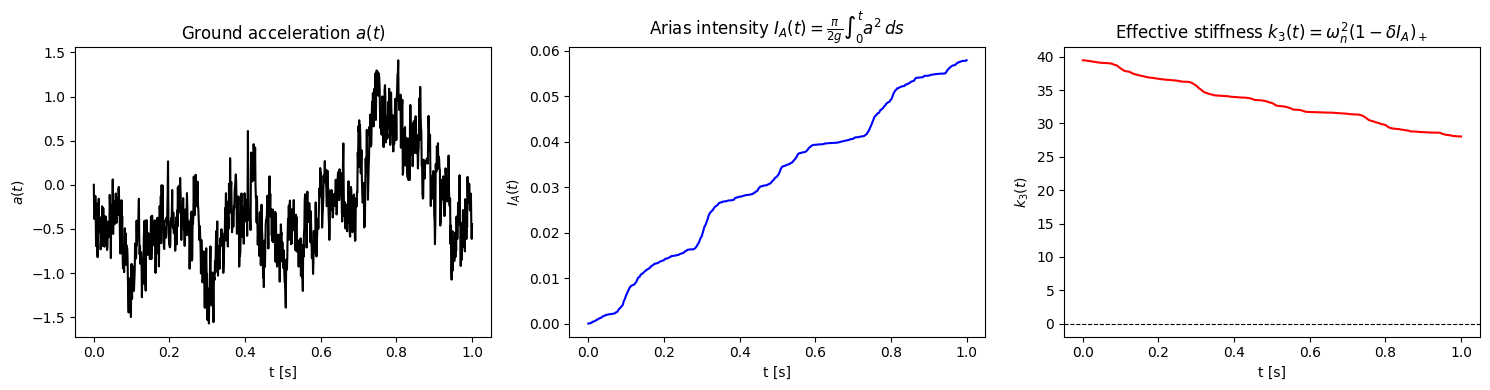

Stiffness remains positive throughout the record.


In [ ]:
# Plot ground acceleration, Arias intensity, and effective stiffness
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

t_np      = x.cpu().numpy()
a_np      = a_ground.cpu().numpy()
IA_np     = IA.cpu().numpy()
k3_np     = k3_profile.cpu().numpy()

axes[0].plot(t_np, a_np, 'k-')
axes[0].set_title("Ground acceleration $a(t)$")
axes[0].set_xlabel("t [s]")
axes[0].set_ylabel("$a(t)$")

axes[1].plot(t_np, IA_np, 'b-')
axes[1].set_title(r"Arias intensity $I_A(t) = \frac{\pi}{2g}\int_0^t a^2\,ds$")
axes[1].set_xlabel("t [s]")
axes[1].set_ylabel("$I_A(t)$")

axes[2].plot(t_np, k3_np, 'r-')
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_title(r"Effective stiffness $k_3(t) = \omega_n^2(1-\delta I_A)_+$")
axes[2].set_xlabel("t [s]")
axes[2].set_ylabel("$k_3(t)$")

plt.tight_layout()
plt.show()

# Report when/if stiffness hits zero
zero_mask = k3_profile == 0
if zero_mask.any():
    t_zero = x[zero_mask.nonzero(as_tuple=True)[0][0]].item()
    print(f"Stiffness reaches zero at t = {t_zero:.3f} s")
else:
    print("Stiffness remains positive throughout the record.")

## Run Solvers and Train Models

In [ ]:
# === Run experiment (Notebook cell) ===
print("Running nonlinear Duffing IVP and signature‑kernel...\n")

# 1) Generate forcing and reference solution
print("solving ivp reference")

x_ref, u_ref = solve_linear_ivp(
    x_grid=x,
    forcing_torch=forcing,
    a=a, b=b,
    ya=ya, ypa=ypa,
    a_fun=a_fun,
    b_fun=b_fun,
    c_fun=c_fun,
)

print("solving plain RBF (no signatures, no extensions)")
urbf, fpred_rbf = solve_rbf_kernel_plain(
        x              = x,
        f              = forcing,
        a_fun=a_fun,
        b_fun=b_fun,
        c_fun=c_fun,
    ua=ya,
    upa=ypa,
    rbfsigma=rbf_sigma,  # reuse the same σ you use for signatures
)


print("solving non branched")
# 2) Non‑branched solver
u_nb, f_pred_nb = \
    solve_signature_kernel_non_branched(
        x              = x,
        f              = forcing,
        a_fun=a_fun,
        b_fun=b_fun,
        c_fun=c_fun,
        ua             = ya,
        upa            = ypa,
        depth          = SIG_DEPTH,
        rbf_sigma      = rbf_sigma,
        kernel_type        = KERNEL_TYPE,
        norm_scheme     = NORM_SCHEME,
        norm_kwargs     = NORM_KWARGS,
    )





# 3) Branched solver
print("Running Branched Solver")
u_sig, snapshots, f_pred_sig, path_ext = \
    solve_signature_kernel_branched(
        x               = x,
        f               = forcing,
        a_fun=a_fun,
        b_fun=b_fun,
        c_fun=c_fun,
        ua              = ya,
        upa             = ypa,
        depth           = SIG_DEPTH,
        adam_iters      = ADAM_ITERS,
        adam_lr         = ADAM_LR,
        ADAM_lambda_model    = ADAM_lambda_model,
        ADAM_lambda_shuffle  = ADAM_lambda_shuffle,
        extensions      = extensions,
        rbf_sigma       = rbf_sigma,
        snapshot_count  = num_snapshots,
        hidden_dims     = HIDDEN_DIMS,
        activation_cls  = ACTIVATION_CLS,
        adam_use_scheduler = ADAM_USE_SCHEDULER,
        adam_sched_factor  = ADAM_SCHED_FACTOR,
        adam_sched_patience= ADAM_SCHED_PATIENCE,
        kernel_type        = KERNEL_TYPE,
        norm_scheme     = NORM_SCHEME,
        norm_kwargs     = NORM_KWARGS,
    )




Running nonlinear Duffing IVP and signature‑kernel...

solving ivp reference
solving plain RBF (no signatures, no extensions)
finding betas (plain RBF kernel)...
time solve betas (RBF): 0.449 s
plain RBF model forcing match loss: 1.324e+01
total time RBF-only: 0.537 s
solving non branched
building Path
  time (build path): 0.000 s
Computing Signatures
  time (compute signatures): 0.005 s
maybe normalizing
  time (normalization): 0.213 s
building kernel from sigs
  time (build kernel): 0.138 s
finding betas, evaluating
  time (solve betas): 0.014 s
betas converged, evaluating forcing loss
  time (forcing loss): 0.000 s
non-branched model forcing match loss: 2.672e-03
total time (non-branched): 0.369 s
Running Branched Solver
[Adam 0050] loss=2.592e-01, PDE=9.466e-05, shuffle=2.583e+03
[Adam 0100] loss=2.756e-01, PDE=6.126e-05, shuffle=2.750e+03
[Adam 0150] loss=7.113e-02, PDE=3.082e-03, shuffle=4.032e+02
[Adam 0200] loss=1.073e-01, PDE=6.491e-03, shuffle=4.239e+02
[Adam 0250] loss=3.878

## Compare Model Metrics and Plot Results


[RBF (no signatures)] solution errors vs IVP:
  MSE(u)      = 1.003e-04
  Abs L2(u)   = 1.001e-02
  Rel L2(u)   = 5.248e-02
[RBF (no signatures)] forcing errors vs true f:
  MSE(f)      = 1.324e+01
  Abs L2(f)   = 3.638e+00
  Rel L2(f)   = 6.168e-01

[Non-branched] solution errors vs IVP:
  MSE(u)      = 6.723e-11
  Abs L2(u)   = 8.200e-06
  Rel L2(u)   = 4.298e-05
[Non-branched] forcing errors vs true f:
  MSE(f)      = 2.672e-03
  Abs L2(f)   = 5.169e-02
  Rel L2(f)   = 8.764e-03

[Branched] solution errors vs IVP:
  MSE(u)      = 2.212e-12
  Abs L2(u)   = 1.487e-06
  Rel L2(u)   = 7.796e-06
  Rel improv vs non branched model = 81.86%
[Branched] forcing errors vs true f:
  MSE(f)      = 4.419e-06
  Abs L2(f)   = 2.102e-03
  Rel L2(f)   = 3.564e-04
  Rel improv vs non branched model = 95.93%


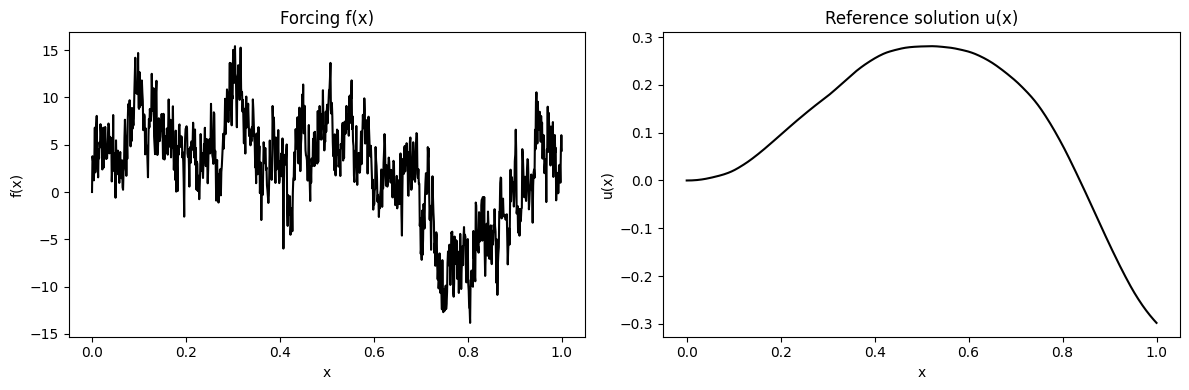

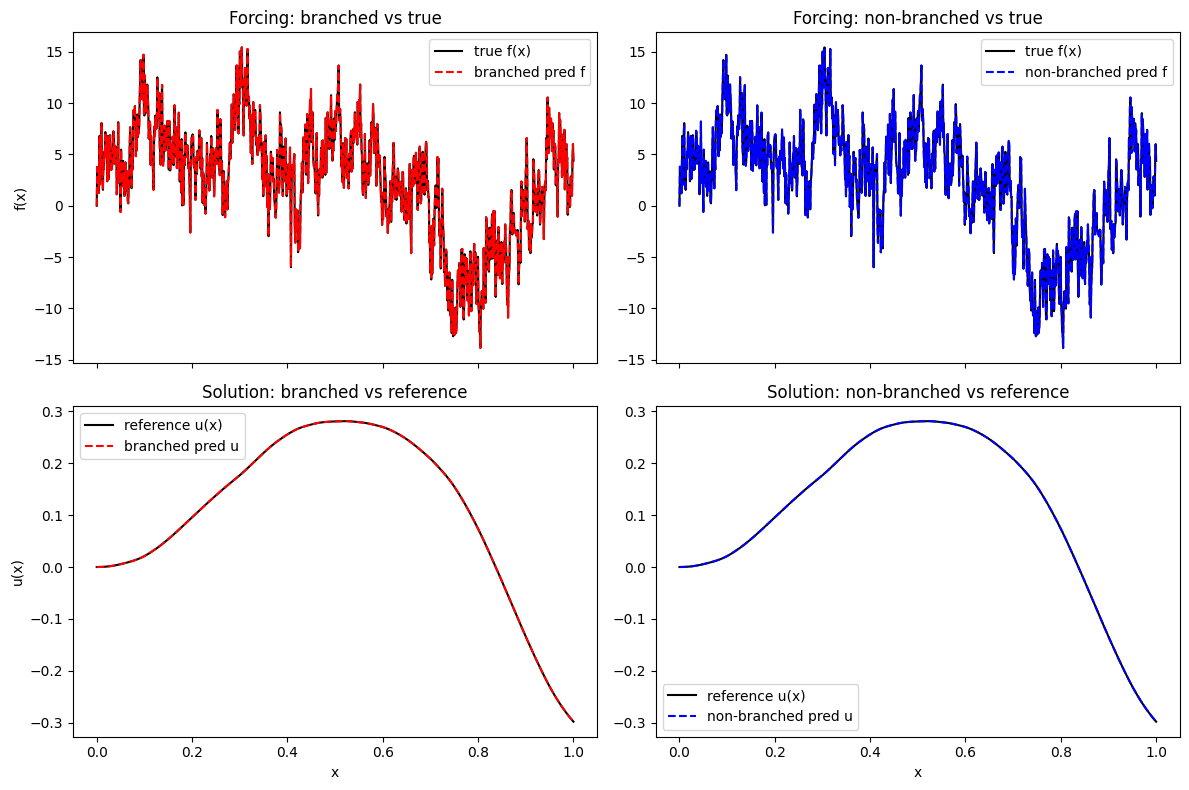

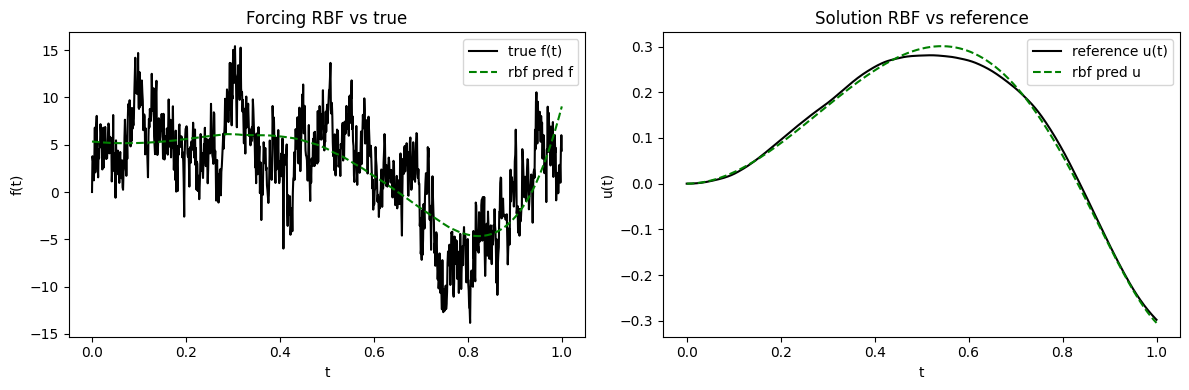

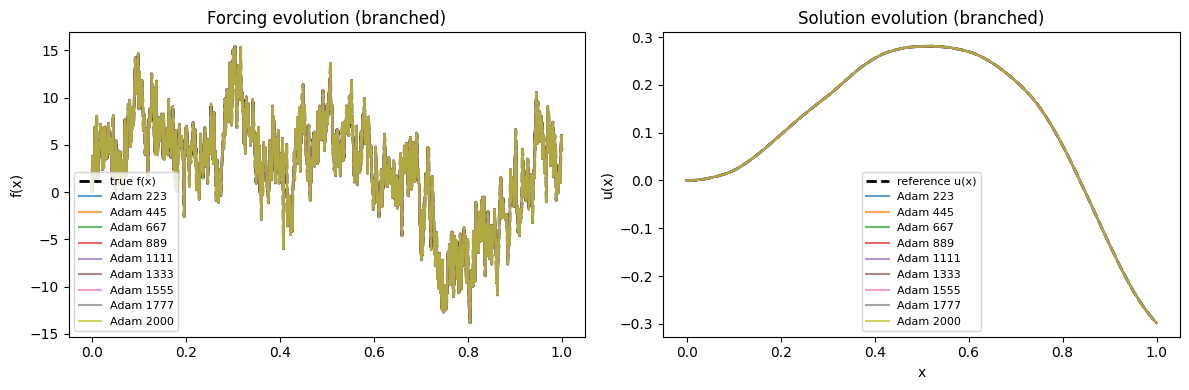

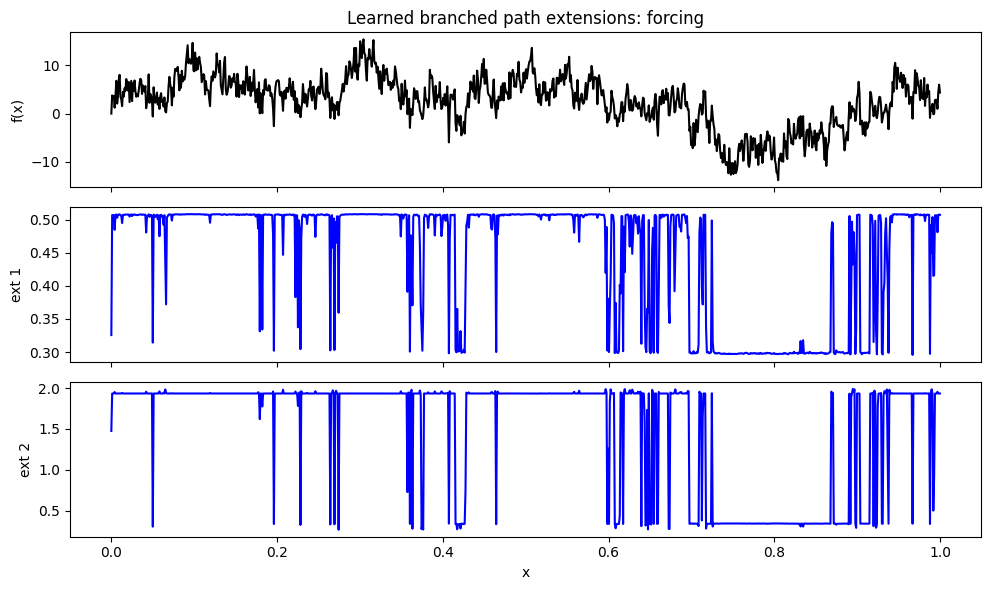

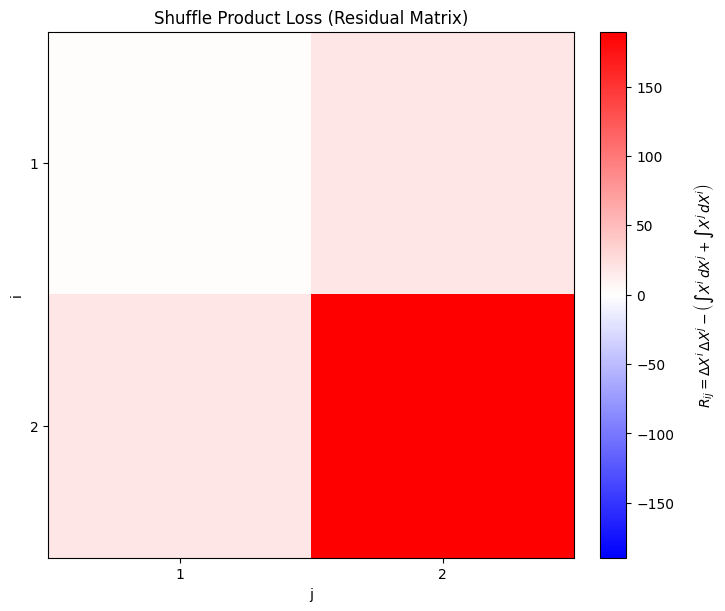


Relative MSE table
Model                   Rel MSE (forcing)   Rel MSE (solution)
--------------------------------------------------------------
RBF                          3.804823e-01         2.754467e-03
Non-branched                 7.681387e-05         1.846994e-09
Branched                     1.270414e-07         6.077516e-11


In [ ]:


  # Print errors for all three models
rel_u_rbf, rel_f_rbf = print_errors("RBF (no signatures)", u_ref, urbf, forcing, fpred_rbf)
rel_u_nb,  rel_f_nb  = print_errors("Non-branched", u_ref, u_nb, forcing, f_pred_nb)
rel_u_sig, rel_f_sig = print_errors("Branched", u_ref, u_sig, forcing, f_pred_sig,
                                    ref_rel_u=rel_u_nb, ref_rel_f=rel_f_nb)

# Main comparison plots
plot_reference_forcing_and_solution(x, forcing, u_ref)
plot_final_comparison_2x2(x, forcing, u_ref, u_sig, f_pred_sig, u_nb, f_pred_nb)

# Final plain RBF plot
plot_rbf_final_comparison(x, forcing, u_ref, urbf, fpred_rbf)

# Snapshot evolution for branched model
plot_snapshot_evolution_branched(x, forcing, u_ref, snapshots)

# Learned extensions
with torch.no_grad():
    X_base = torch.stack([x, forcing], dim=1)
    learned_ext = path_ext(X_base)
    X_full_ext = torch.cat([X_base, learned_ext], dim=1)

plot_learned_extensions(x, forcing, X_full_ext, title_prefix="Learned branched path extensions")
plot_shuffle_residual_matrix(x, forcing, path_ext)

# Relative MSE table
mse_u_rbf, relmse_u_rbf = compute_mse_and_relative_mse(u_ref, urbf)
mse_f_rbf, relmse_f_rbf = compute_mse_and_relative_mse(forcing, fpred_rbf)

mse_u_nb, relmse_u_nb = compute_mse_and_relative_mse(u_ref, u_nb)
mse_f_nb, relmse_f_nb = compute_mse_and_relative_mse(forcing, f_pred_nb)

mse_u_sig, relmse_u_sig = compute_mse_and_relative_mse(u_ref, u_sig)
mse_f_sig, relmse_f_sig = compute_mse_and_relative_mse(forcing, f_pred_sig)

print("\nRelative MSE table")
print(f"{'Model':<20} {'Rel MSE (forcing)':>20} {'Rel MSE (solution)':>20}")
print("-" * 62)
print(f"{'RBF':<20} {relmse_f_rbf:>20.6e} {relmse_u_rbf:>20.6e}")
print(f"{'Non-branched':<20} {relmse_f_nb:>20.6e} {relmse_u_nb:>20.6e}")
print(f"{'Branched':<20} {relmse_f_sig:>20.6e} {relmse_u_sig:>20.6e}")

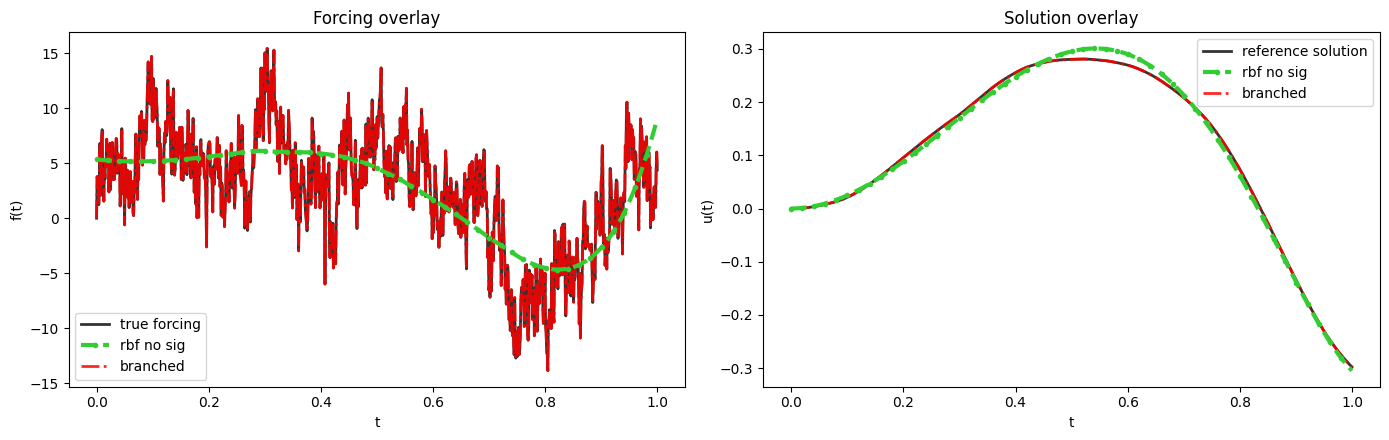

In [ ]:

plot_overlay_reference_rbf_branched_1x2(
    x=x,
    f_true=forcing,
    u_ref=u_ref,
    f_rbf=fpred_rbf,
    u_rbf=urbf,
    f_sig=f_pred_sig,
    u_sig=u_sig
)